# 05 - Functional Enrichment: RV (with Hb-adjustment comparison)

Runs the **same enrichment analysis** on **two parallel RV DEG lists**:

1. **Unadjusted** (`~ Sex + Exposure`)
2. **Hb-adjusted** (`~ Sex + pct_hb + Exposure`)

Then compares the pathway-level results side-by-side. This is the
high-level test of whether covariate adjustment is doing what we hoped:
removing contamination-driven pathways while preserving cardiac-driven ones.

**Hypothesis if adjustment is working:**
- Unadjusted-only enriched pathways should be enriched for "leukocyte chemotaxis,"
  "inflammatory response," etc. — these are contamination signatures.
- Adjusted-only enriched pathways should be cardiac-specific — "cardiac muscle
  contraction," "calcium handling," "hypertrophy," etc.
- Pathways enriched in both are the **most robust** — defensible findings.

## 1. Setup

In [1]:
library(tidyverse)
library(clusterProfiler)
library(enrichplot)
library(msigdbr)
library(openxlsx)
library(RColorBrewer)
library(ggrepel)

source("~/project_pi_epm38/jfd42/pipelines/functional_enrichment/enrichment_utils.R")

options(repr.plot.width = 11, repr.plot.height = 8)
set.seed(42)
Sys.time()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


clusterProfiler v4.10.0  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:purrr’:

    simplif

[1] "2026-07-31 14:10:59 EDT"

## 2. Configuration

In [2]:
CONTRASTS <- list(
  Hb_adjusted = list(
    csv = "results_rv_HbAdjusted/RV_Exposure_Crystalline_vs_CTRL_full_results.csv",
    label = "RV_HbAdj"
  )
)

OUTPUT_DIR <- "enrichment_rv"
PLOTS_DIR  <- file.path(OUTPUT_DIR, "plots")
dir.create(PLOTS_DIR, recursive = TRUE, showWarnings = FALSE)

PADJ_THRESHOLD <- 0.05
LFC_THRESHOLD  <- 1.5
SPECIES <- "Mus musculus"
TOP_N_PATHWAYS <- 20

cat("Configuration:\n")
for (nm in names(CONTRASTS)) {
  cat("  -", nm, ":", CONTRASTS[[nm]]$csv, "\n")
}

Configuration:
  - Hb_adjusted : results_rv_HbAdjusted/RV_Exposure_Crystalline_vs_CTRL_full_results.csv 


## 3. Load gene set collections

In [3]:
collections <- load_all_collections(species = SPECIES)
cat("\nLoaded", length(collections), "collections.\n")

Loading 4 gene set collections for Mus musculus ...
   Hallmark ...

Using human MSigDB with ortholog mapping to mouse. Use `db_species = "MM"` for mouse-native gene sets.
This message is displayed once per session.


 loaded 50 gene sets
   GO_BP ... loaded 7580 gene sets
   KEGG ... loaded 186 gene sets
   Reactome ... loaded 1787 gene sets

Loaded 4 collections.


## 4. Run ORA for each contrast

In [4]:
# Loop over contrasts and run the full ORA analysis for each
all_ora <- list()

for (contrast_name in names(CONTRASTS)) {
  cat("\n", strrep("=", 70), "\n", sep = "")
  cat("Processing contrast:", contrast_name, "\n")
  cat(strrep("=", 70), "\n")

  # Load DESeq2 results
  results_df <- read.csv(CONTRASTS[[contrast_name]]$csv,
                          stringsAsFactors = FALSE)
  cat("Loaded", nrow(results_df), "genes from",
      CONTRASTS[[contrast_name]]$csv, "\n\n")

  # Prepare ORA input
  ora_input <- prepare_ora_input(results_df,
                                  padj_threshold = PADJ_THRESHOLD,
                                  lfc_threshold  = LFC_THRESHOLD,
                                  symbol_col     = "gene_name")

  # Run all collections × directions
  ora_results <- run_ora_all_collections(
    ora_input   = ora_input,
    collections = collections,
    directions  = c("all", "up", "down"),
    padj_cutoff = PADJ_THRESHOLD
  )

  # Save outputs with the contrast label
  save_all_ora_results(ora_results, OUTPUT_DIR, CONTRASTS[[contrast_name]]$label)

  all_ora[[contrast_name]] <- ora_results
}

cat("\n=== Done ===\n")


Processing contrast: Hb_adjusted 
Loaded 21117 genes from results_rv_HbAdjusted/RV_Exposure_Crystalline_vs_CTRL_full_results.csv 

ORA input prepared:
  Background genes:     21117 
  Significant (any):    1100 
  Significant (UP):     289 
  Significant (DOWN):   811 

=== Collection: Hallmark ===
  Direction: all ( 1100 genes) ...    1 significant pathways at padj < 0.05 
  Direction: up ( 289 genes) ...    1 significant pathways at padj < 0.05 
  Direction: down ( 811 genes) ...    2 significant pathways at padj < 0.05 

=== Collection: GO_BP ===
  Direction: all ( 1100 genes) ...    0 significant pathways at padj < 0.05 
  Direction: up ( 289 genes) ...    14 significant pathways at padj < 0.05 
  Direction: down ( 811 genes) ...    4 significant pathways at padj < 0.05 

=== Collection: KEGG ===
  Direction: all ( 1100 genes) ...    0 significant pathways at padj < 0.05 
  Direction: up ( 289 genes) ...    0 significant pathways at padj < 0.05 
  Direction: down ( 811 genes) ... 

## 5. Visualize ORA per contrast

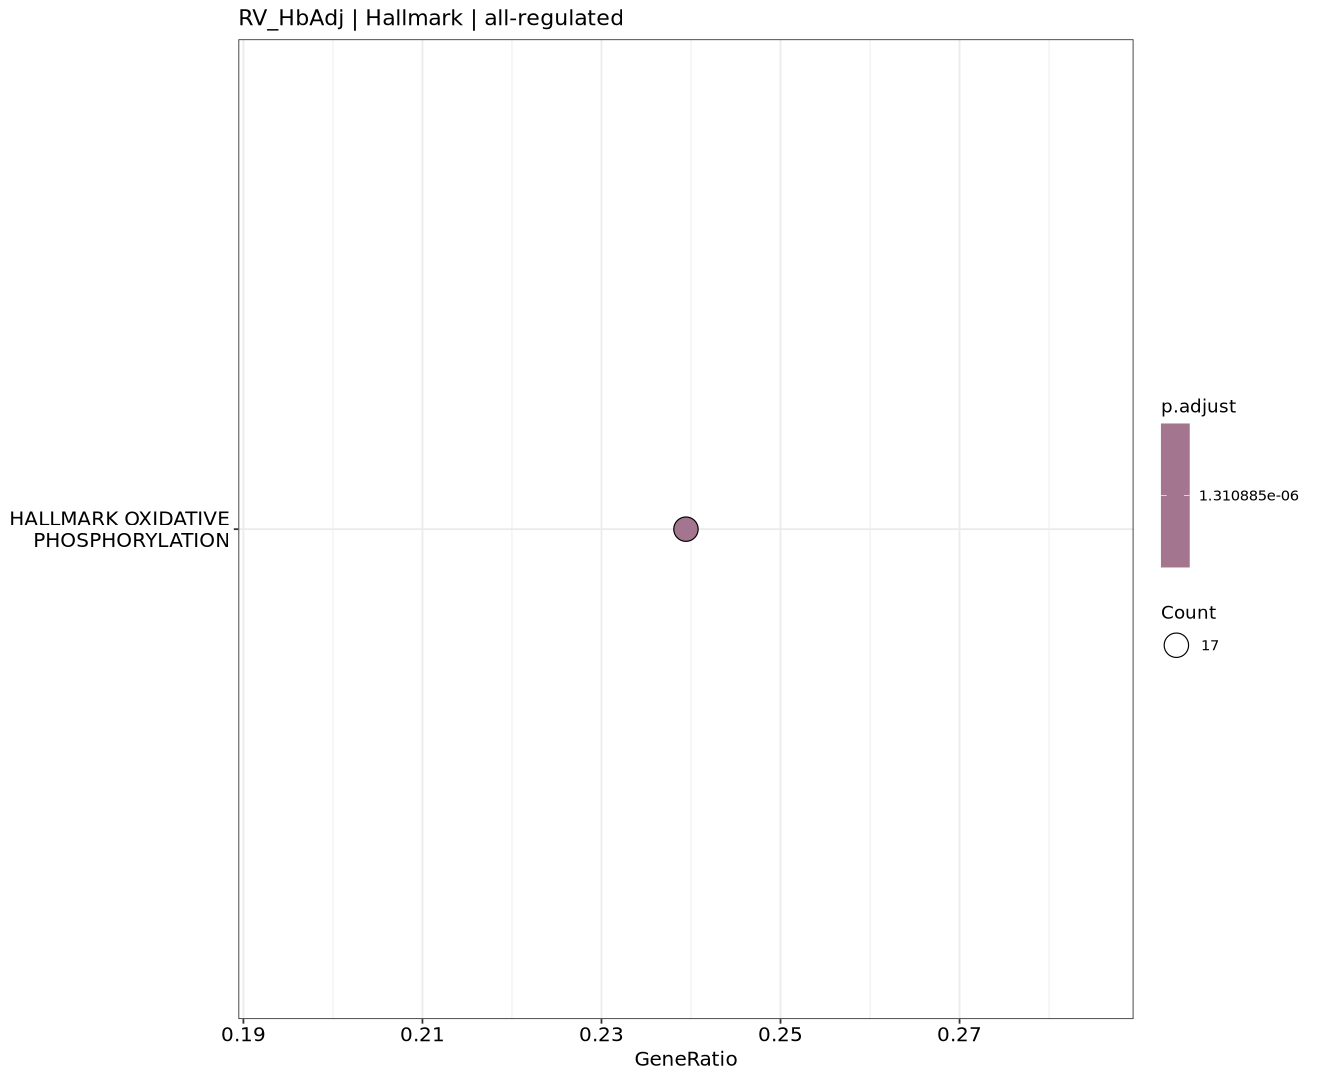

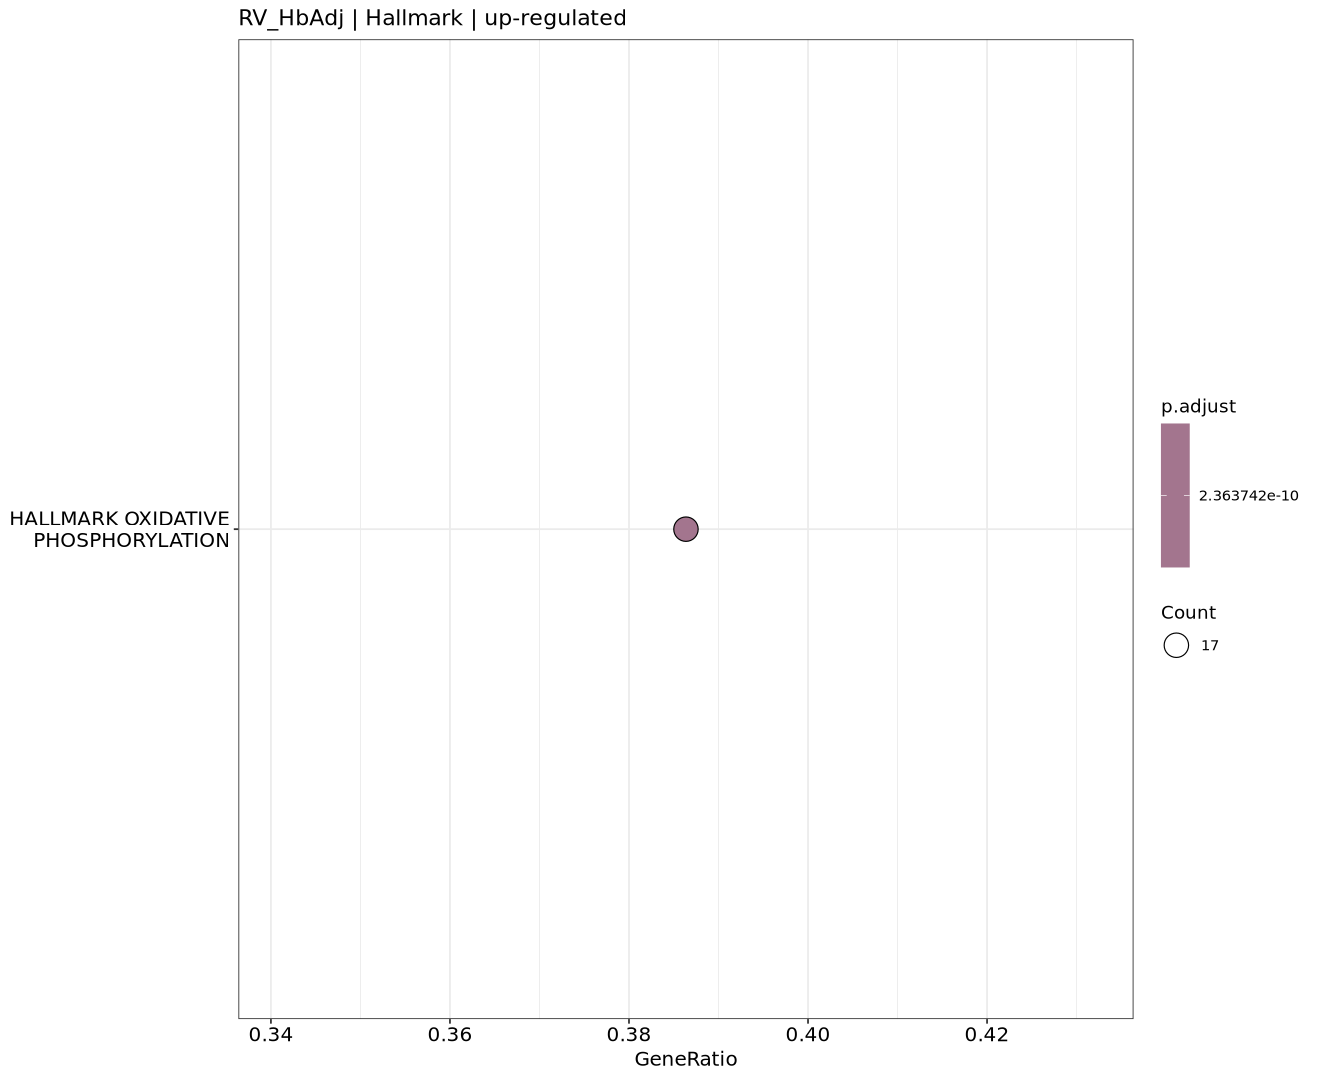

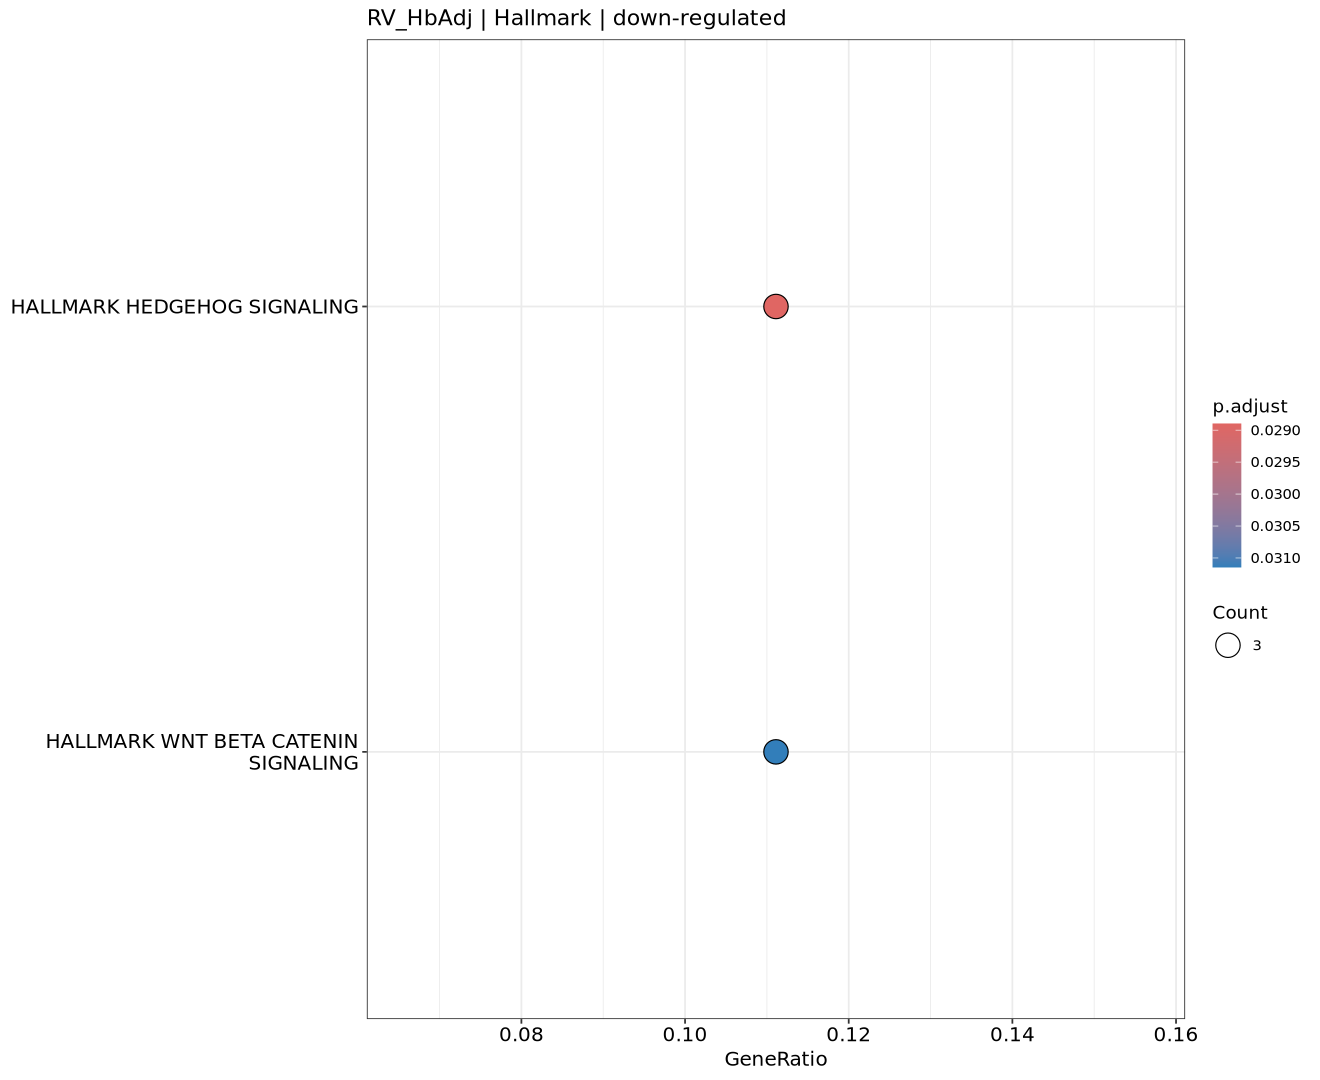

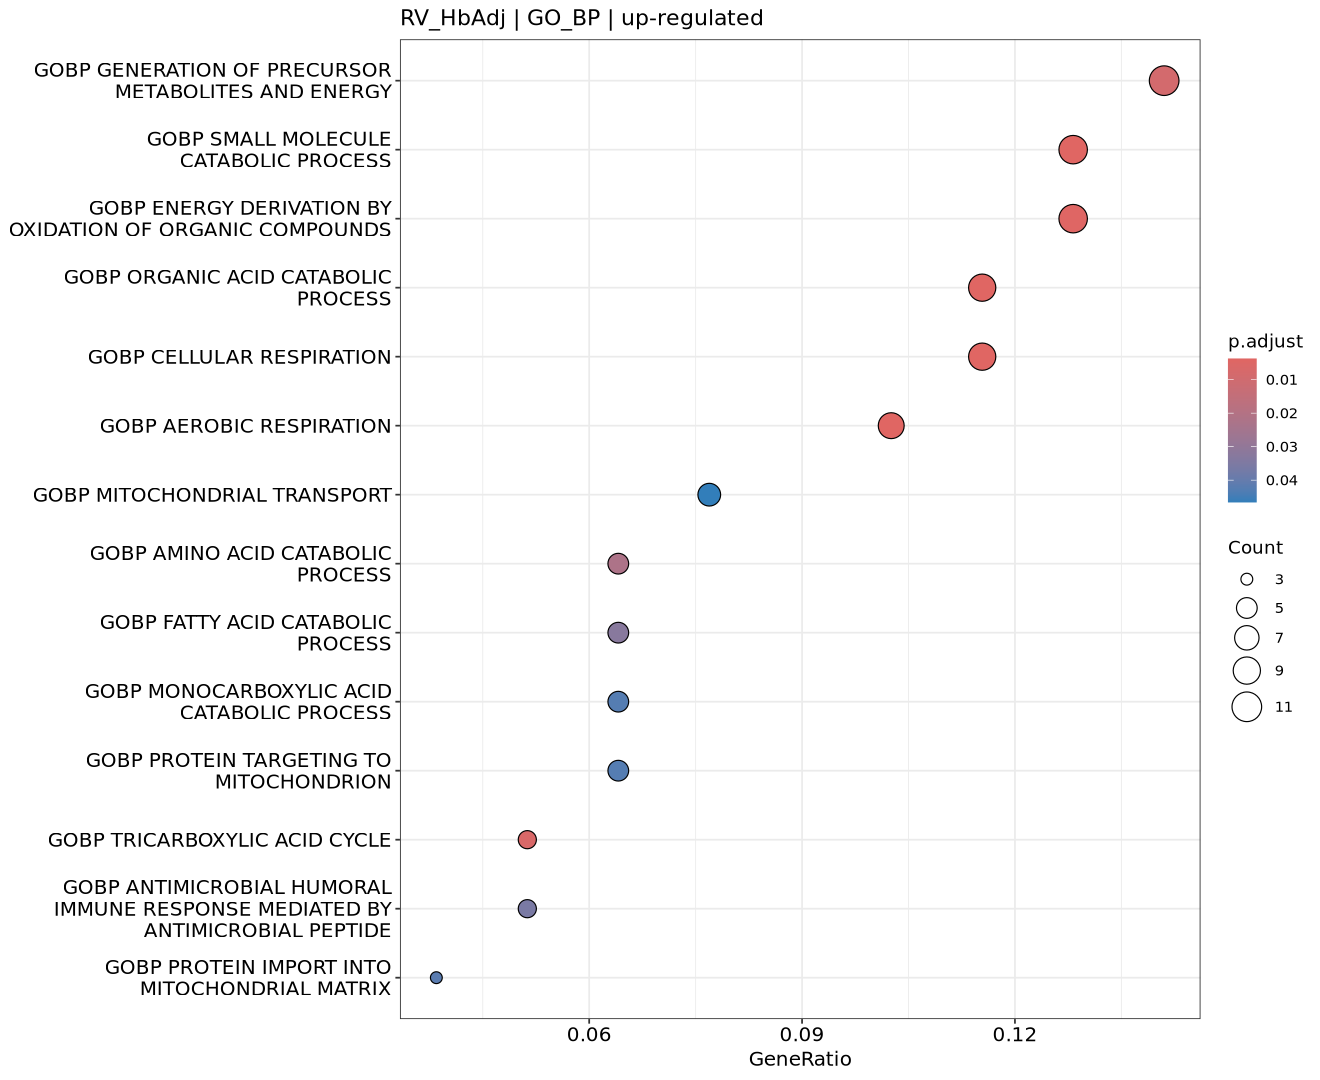

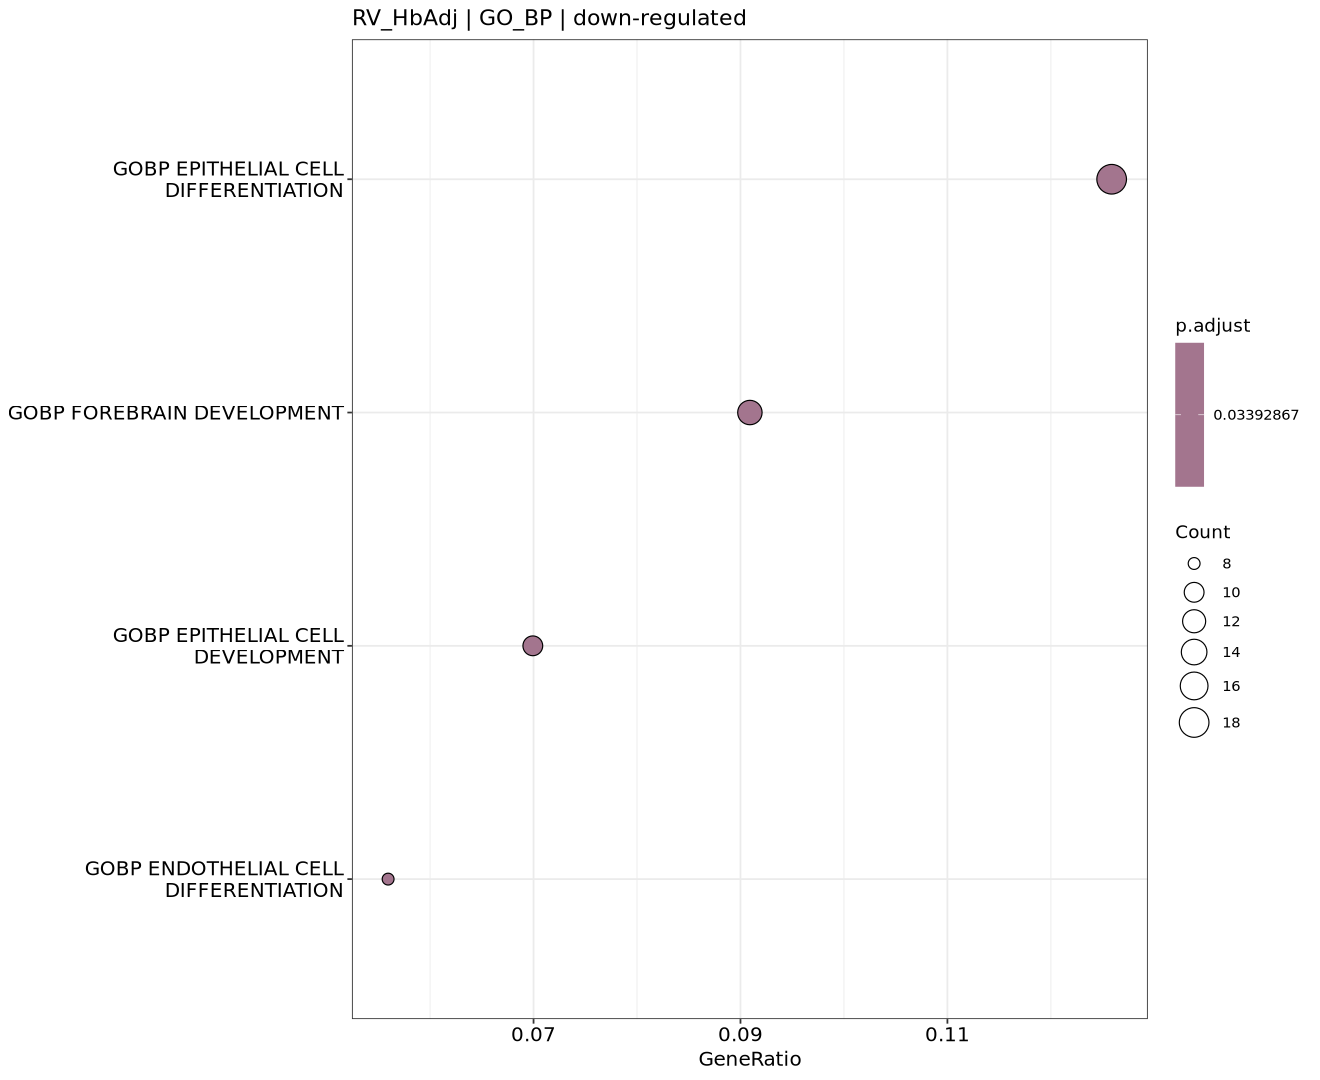

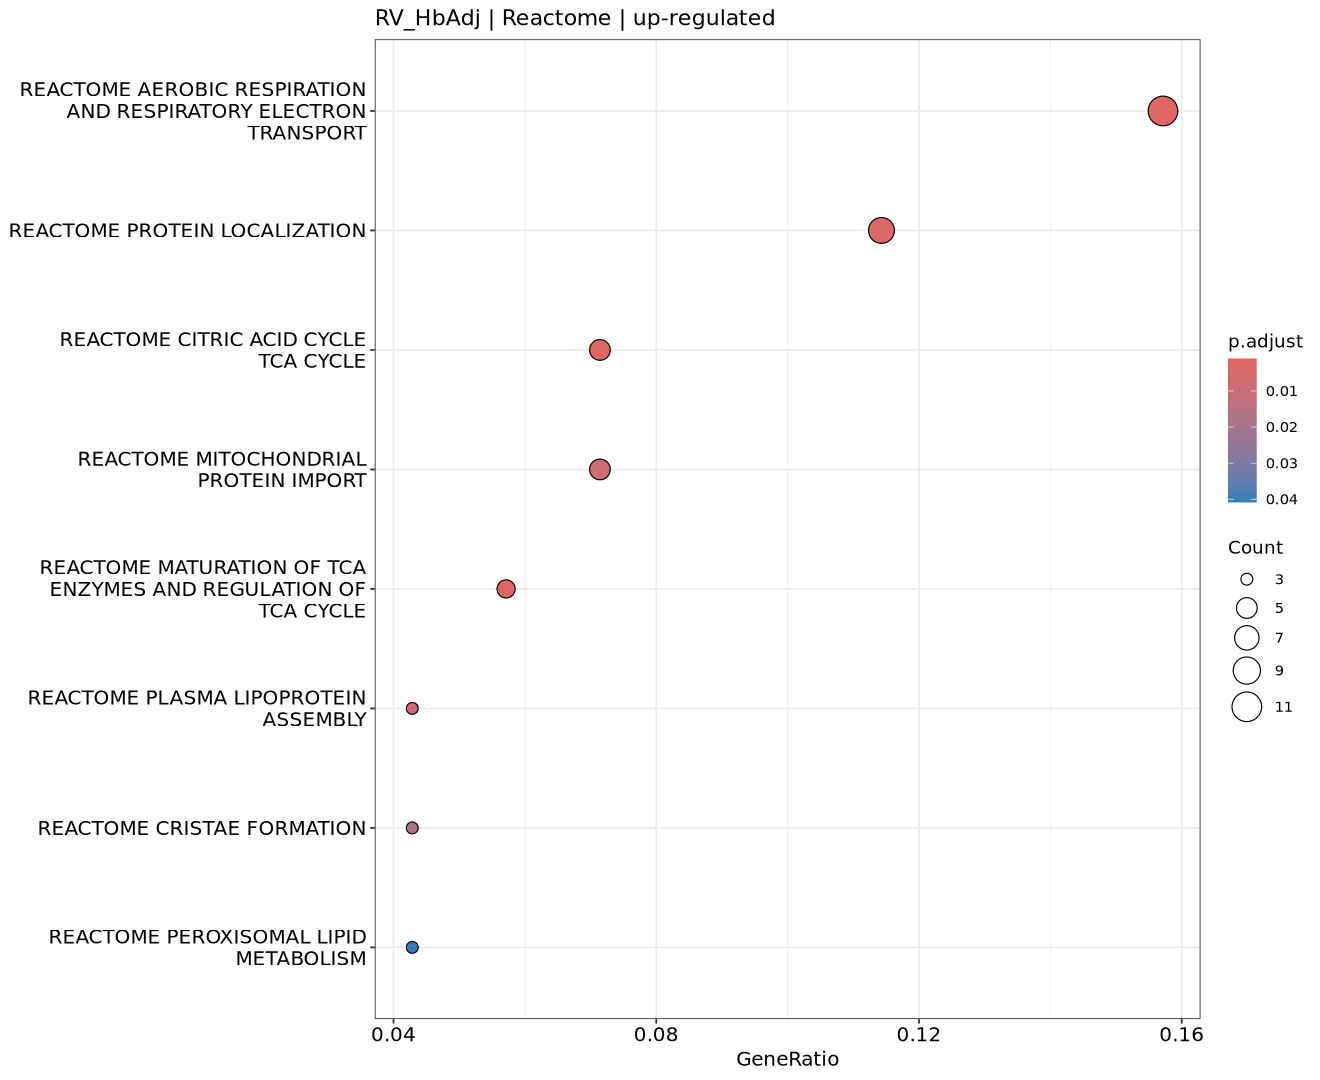

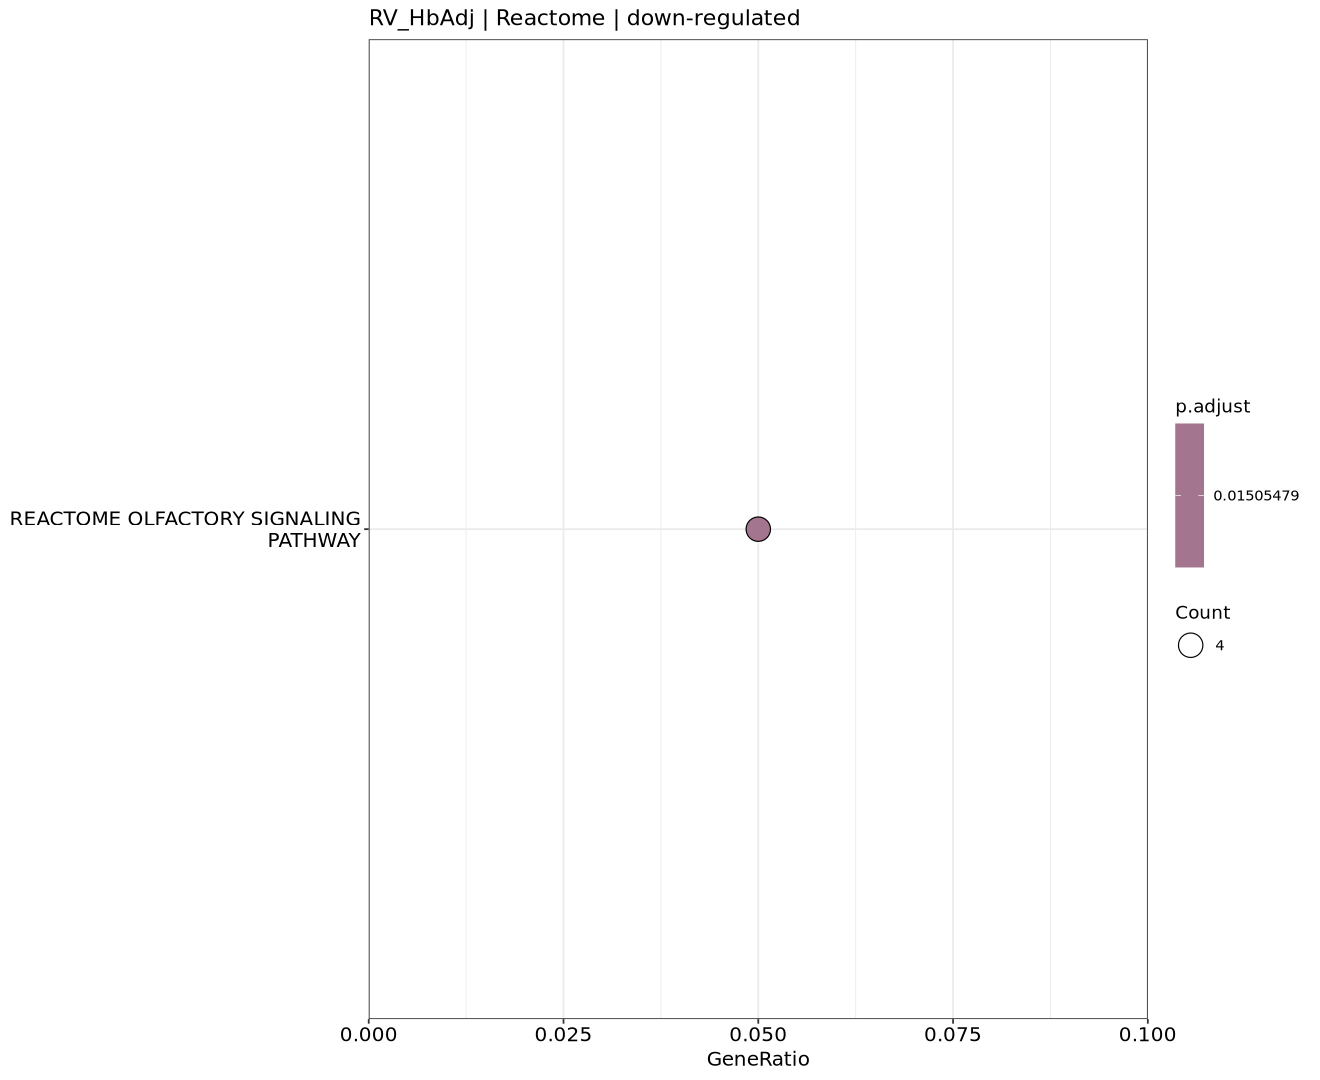

In [5]:
# Walk through and plot each
options(repr.plot.width = 11, repr.plot.height = 9)
for (contrast_name in names(all_ora)) {
  for (coll in names(all_ora[[contrast_name]])) {
    for (dir in names(all_ora[[contrast_name]][[coll]])) {
      res <- all_ora[[contrast_name]][[coll]][[dir]]
      if (is.null(res) || nrow(as.data.frame(res)) == 0) next

      title <- paste0(CONTRASTS[[contrast_name]]$label, " | ",
                      coll, " | ", dir, "-regulated")
      p <- plot_ora_dotplot(res, show_n = TOP_N_PATHWAYS, title = title)
      if (!is.null(p)) {
        print(p)
        ggsave(file.path(PLOTS_DIR,
                          paste0(CONTRASTS[[contrast_name]]$label,
                                 "_ORA_", coll, "_", dir, "_dotplot.pdf")),
               p, width = 11, height = max(6, min(14, TOP_N_PATHWAYS * 0.4)))
      }
    }
  }
}

## 6. GSEA

In [6]:
all_gsea <- list()

for (contrast_name in names(CONTRASTS)) {
  cat("\n", strrep("=", 70), "\n", sep = "")
  cat("GSEA for:", contrast_name, "\n")
  cat(strrep("=", 70), "\n")

  results_df <- read.csv(CONTRASTS[[contrast_name]]$csv,
                          stringsAsFactors = FALSE)
  gene_list <- prepare_gsea_input(results_df, metric = "lfc",
                                    symbol_col = "gene_name")

  gsea_results <- run_gsea_all_collections(
    gene_list = gene_list,
    collections = collections,
    padj_cutoff = PADJ_THRESHOLD,
    seed = 42
  )

  save_all_gsea_results(gsea_results, OUTPUT_DIR, CONTRASTS[[contrast_name]]$label)
  all_gsea[[contrast_name]] <- gsea_results
}


GSEA for: Hb_adjusted 
GSEA input prepared:
  Total ranked genes: 21117 
  Range:             -6.05 to 4.2 

=== Collection: Hallmark ===
  Running GSEA ... 

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.38% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation.”


   17 significant gene sets at padj < 0.05 

=== Collection: GO_BP ===
  Running GSEA ... 

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.38% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation.”


   246 significant gene sets at padj < 0.05 

=== Collection: KEGG ===
  Running GSEA ... 

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.38% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation.”


   25 significant gene sets at padj < 0.05 

=== Collection: Reactome ===
  Running GSEA ... 

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.38% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation.”


   280 significant gene sets at padj < 0.05 
  Saved RV_HbAdj_GSEA_Hallmark ( 17 rows)
  Saved RV_HbAdj_GSEA_GO_BP ( 246 rows)
  Saved RV_HbAdj_GSEA_KEGG ( 25 rows)
  Saved RV_HbAdj_GSEA_Reactome ( 280 rows)


## 6b. DEG × Hallmark overlap (pick genes to label on the volcano)

For each contrast in `CONTRASTS`, and for each Hallmark pathway, this lists which
of that contrast's DEGs (|log2FC| >= `LFC_THRESHOLD` and `padj` < `PADJ_THRESHOLD`)
are members of the pathway's gene set. The point is to prioritise labelling genes
that are both differentially expressed **and** part of a biologically meaningful
pathway.

Per contrast it builds:
- `overlap_long`    : one row per DEG × pathway membership.
- `deg_summary`     : one row per DEG, ranked by how many Hallmark pathways it
  drives and which ones — scan this to build your label list.

Results are collected in the `all_deg_hallmark` list (keyed by contrast) and
written to CSV. Nothing here changes the analysis; it only produces tables to
inform which gene symbols you hand to the volcano plot in notebook `01`.

In [7]:
# === DEG x Hallmark overlap (per contrast) ==================================
# Uses CONTRASTS + the Hallmark collection in `collections`. Reads each
# contrast's full-results CSV fresh (same files GSEA/ORA used).

suppressPackageStartupMessages(library(dplyr))

hallmark_tbl <- collections[["Hallmark"]]

# msigdbr column names vary by version; auto-detect the gene-symbol column.
sym_candidates <- c("gene_symbol", "mouse_gene_symbol", "symbol",
                    "gene_name", "ortholog_symbol")
gene_col <- sym_candidates[sym_candidates %in% colnames(hallmark_tbl)][1]
set_col  <- if ("gs_name" %in% colnames(hallmark_tbl)) "gs_name" else
            colnames(hallmark_tbl)[grepl("gs_name|pathway|set", colnames(hallmark_tbl))][1]
stopifnot(!is.na(gene_col), !is.na(set_col))
cat("Using Hallmark gene column:", gene_col, "| set column:", set_col, "\n")

hallmark_membership <- hallmark_tbl %>%
  transmute(pathway = .data[[set_col]],
            gene_name = .data[[gene_col]]) %>%
  distinct()

overlap_dir <- file.path(OUTPUT_DIR, "deg_hallmark_overlap")
dir.create(overlap_dir, recursive = TRUE, showWarnings = FALSE)

all_deg_hallmark <- list()

for (contrast_name in names(CONTRASTS)) {
  cat("\n", strrep("=", 70), "\n", sep = "")
  cat("DEG x Hallmark overlap for:", contrast_name, "\n")
  cat(strrep("=", 70), "\n")

  results_df <- read.csv(CONTRASTS[[contrast_name]]$csv,
                          stringsAsFactors = FALSE)
  lbl <- CONTRASTS[[contrast_name]]$label

  # 1. DEG set from the DESeq2 results.
  deg_df <- results_df %>%
    filter(!is.na(padj),
           padj < PADJ_THRESHOLD,
           abs(log2FoldChange) >= LFC_THRESHOLD) %>%
    mutate(direction = ifelse(log2FoldChange > 0, "up", "down")) %>%
    select(gene_name, log2FoldChange, padj, direction)
  cat("DEGs (|LFC| >=", LFC_THRESHOLD, "& padj <", PADJ_THRESHOLD, "):",
      nrow(deg_df), "\n")

  # 2. Long overlap: one row per (DEG, pathway) membership.
  overlap_long <- deg_df %>%
    inner_join(hallmark_membership, by = "gene_name") %>%
    arrange(desc(abs(log2FoldChange)), gene_name, pathway)
  cat("DEGs in >=1 Hallmark pathway:",
      dplyr::n_distinct(overlap_long$gene_name),
      "| membership rows:", nrow(overlap_long), "\n\n")

  # 3. Per-gene summary: how many Hallmark pathways each DEG drives.
  deg_summary <- overlap_long %>%
    group_by(gene_name, log2FoldChange, padj, direction) %>%
    summarise(n_hallmark_pathways = dplyr::n(),
              hallmark_pathways = paste(sort(unique(pathway)), collapse = "; "),
              .groups = "drop") %>%
    arrange(desc(n_hallmark_pathways), padj)

  cat("=== Top DEGs by number of Hallmark pathways (", contrast_name, ") ===\n")
  print(head(as.data.frame(deg_summary), 30))

  # 4. DEGs NOT in any Hallmark pathway (for reference).
  degs_no_hallmark <- deg_df %>%
    filter(!gene_name %in% overlap_long$gene_name) %>%
    arrange(padj)
  cat("\nDEGs NOT in any Hallmark pathway:", nrow(degs_no_hallmark), "\n")

  # 5. Save.
  write.csv(overlap_long,
            file.path(overlap_dir, paste0(lbl, "_DEG_hallmark_long.csv")),
            row.names = FALSE)
  write.csv(deg_summary,
            file.path(overlap_dir, paste0(lbl, "_DEG_hallmark_summary.csv")),
            row.names = FALSE)

  all_deg_hallmark[[contrast_name]] <- list(
    overlap_long    = overlap_long,
    deg_summary     = deg_summary,
    degs_no_hallmark = degs_no_hallmark
  )
}

cat("\nSaved overlap tables to:", overlap_dir, "\n")

# --- Optional: restrict to Hallmark pathways significant in GSEA -------------
# If you only care about drivers of pathways that actually came up enriched,
# uncomment to re-summarise using GSEA-significant Hallmark sets per contrast.
#
# for (contrast_name in names(CONTRASTS)) {
#   sig_hallmark <- as.data.frame(all_gsea[[contrast_name]][["Hallmark"]])$ID
#   sig_summary <- all_deg_hallmark[[contrast_name]]$overlap_long %>%
#     filter(pathway %in% sig_hallmark) %>%
#     group_by(gene_name, log2FoldChange, padj, direction) %>%
#     summarise(n_sig_hallmark = dplyr::n(),
#               sig_hallmark_pathways = paste(sort(unique(pathway)), collapse = "; "),
#               .groups = "drop") %>%
#     arrange(desc(n_sig_hallmark), padj)
#   cat("\n### GSEA-significant Hallmark drivers:", contrast_name, "###\n")
#   print(head(as.data.frame(sig_summary), 30))
# }


Using Hallmark gene column: gene_symbol | set column: gs_name 

DEG x Hallmark overlap for: Hb_adjusted 
DEGs (|LFC| >= 1.5 & padj < 0.05 ): 1100 
DEGs in >=1 Hallmark pathway: 71 | membership rows: 128 

=== Top DEGs by number of Hallmark pathways ( Hb_adjusted ) ===
   gene_name log2FoldChange         padj direction n_hallmark_pathways
1     Ifngr2       1.888755 2.896496e-07        up                   5
2       Glrx       1.829711 8.529596e-07        up                   5
3     Notch1      -1.879945 2.915797e-10      down                   4
4       Ccl7       1.601279 1.027211e-06        up                   4
5    Tpd52l1       1.634234 7.056162e-06        up                   4
6      Cxcl5       1.787342 5.095571e-03        up                   4
7       Ctss       1.593678 3.154413e-10        up                   3
8      Eif4e       1.667005 1.005863e-07        up                   3
9     Grpel1       1.612513 1.306842e-07        up                   3
10     Prdx3       1.

In [8]:
# === Pathway-driver gene tables (Panther-style supplemental) ===
# One Excel workbook per contrast, with sheets for each collection
# (GSEA Hallmark/GOBP/KEGG/Reactome and ORA up/down per collection).

DRIVER_OUTPUT_DIR <- file.path(OUTPUT_DIR, "pathway_driver_tables")
dir.create(DRIVER_OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)

for (contrast_name in names(CONTRASTS)) {
  cat("\n", strrep("=", 70), "\n", sep = "")
  cat("Driver tables for:", contrast_name, "\n")
  cat(strrep("=", 70), "\n")

  out_xlsx <- file.path(DRIVER_OUTPUT_DIR,
                        paste0(CONTRASTS[[contrast_name]]$label,
                               "_pathway_drivers.xlsx"))

  write_pathway_driver_workbook(
    gsea_results = all_gsea[[contrast_name]],
    ora_results  = all_ora[[contrast_name]],
    output_path  = out_xlsx,
    max_pathways_per_sheet = 50
  )
}


Driver tables for: Hb_adjusted 
  Wrote sheet: GSEA_Hallmark ( 17 pathways)
  Wrote sheet: GSEA_GO_BP ( 50 pathways)
  Wrote sheet: GSEA_KEGG ( 25 pathways)
  Wrote sheet: GSEA_Reactome ( 50 pathways)
  Wrote sheet: ORA_Hallmark_all ( 1 pathways)
  Wrote sheet: ORA_Hallmark_up ( 1 pathways)
  Wrote sheet: ORA_Hallmark_down ( 2 pathways)
  ORA / GO_BP / all: no pathways to write
  Wrote sheet: ORA_GO_BP_up ( 14 pathways)
  Wrote sheet: ORA_GO_BP_down ( 4 pathways)
  ORA / KEGG / all: no pathways to write
  ORA / KEGG / up: no pathways to write
  ORA / KEGG / down: no pathways to write
  ORA / Reactome / all: no pathways to write
  Wrote sheet: ORA_Reactome_up ( 8 pathways)
  Wrote sheet: ORA_Reactome_down ( 1 pathways)

Saved pathway-driver workbook: enrichment_rv/pathway_driver_tables/RV_HbAdj_pathway_drivers.xlsx 


### GSEA dotplots

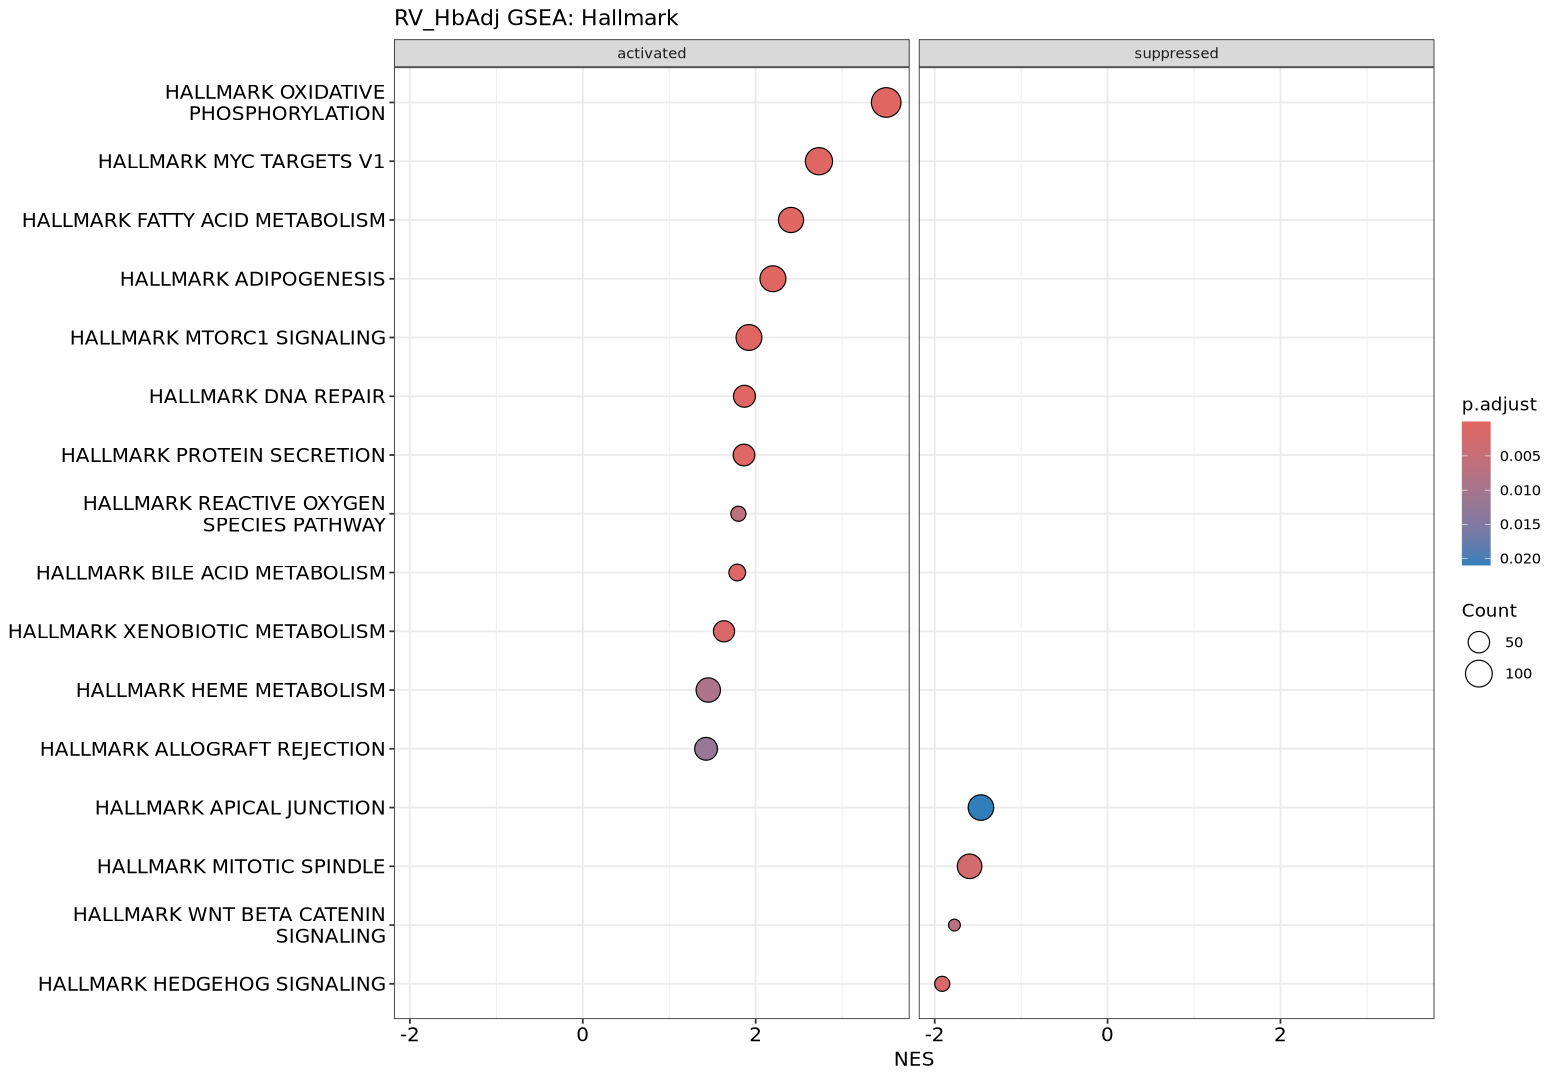

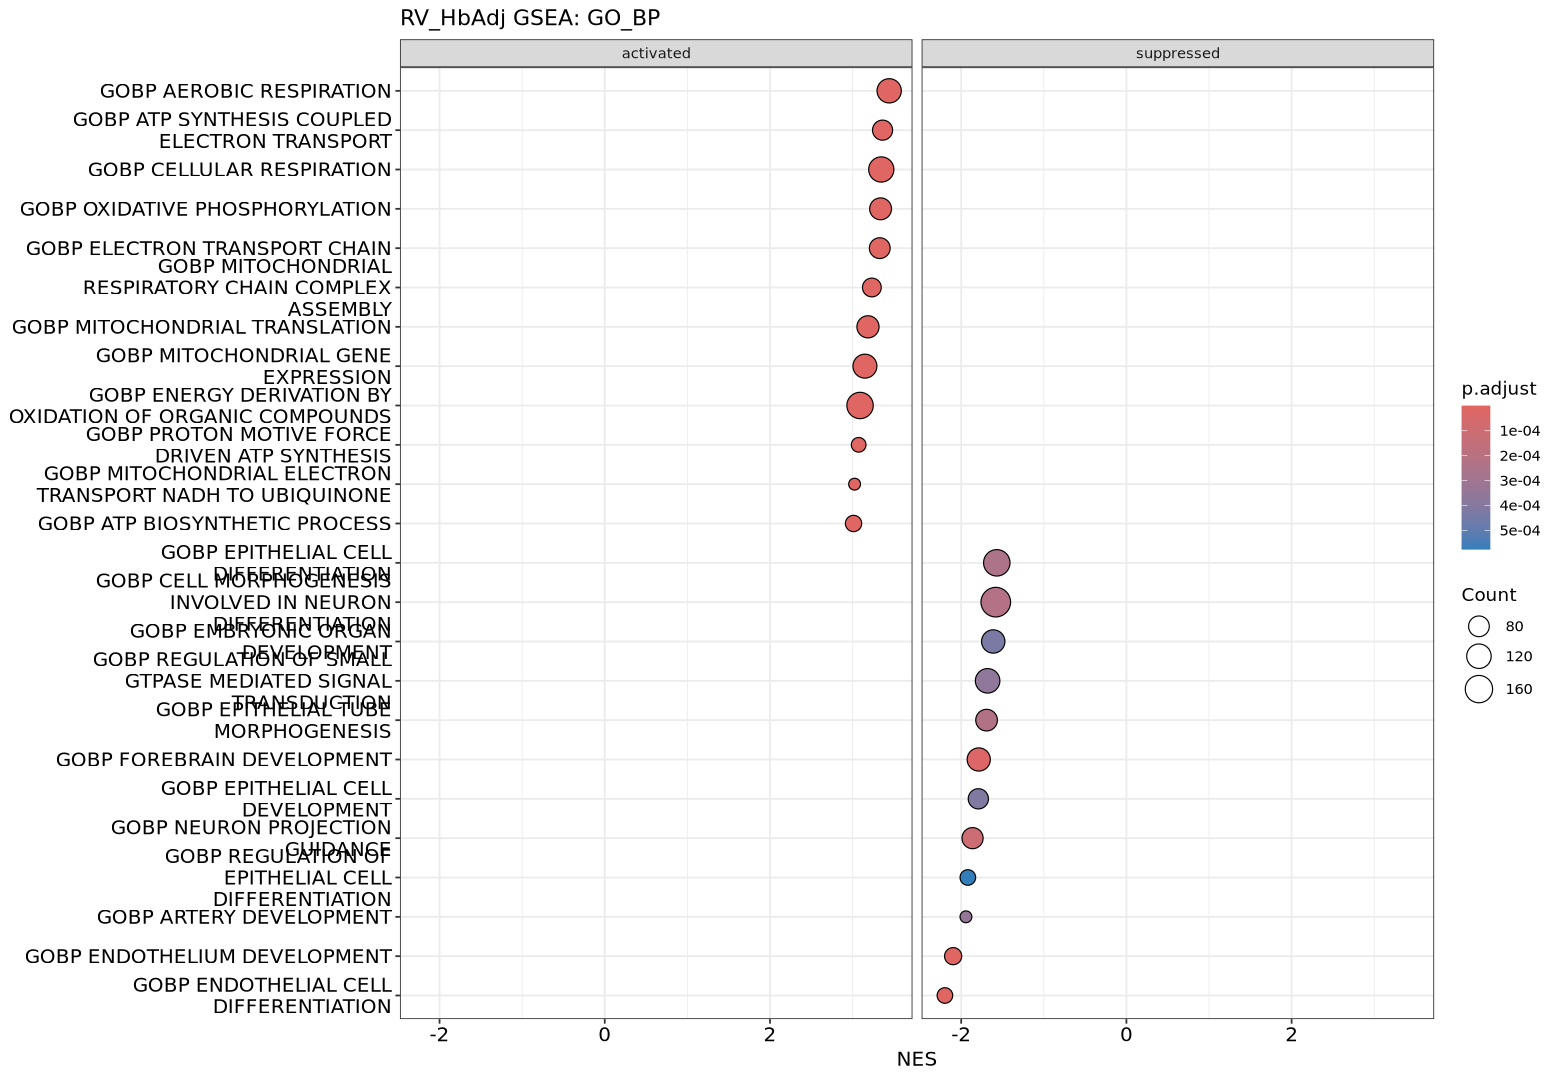

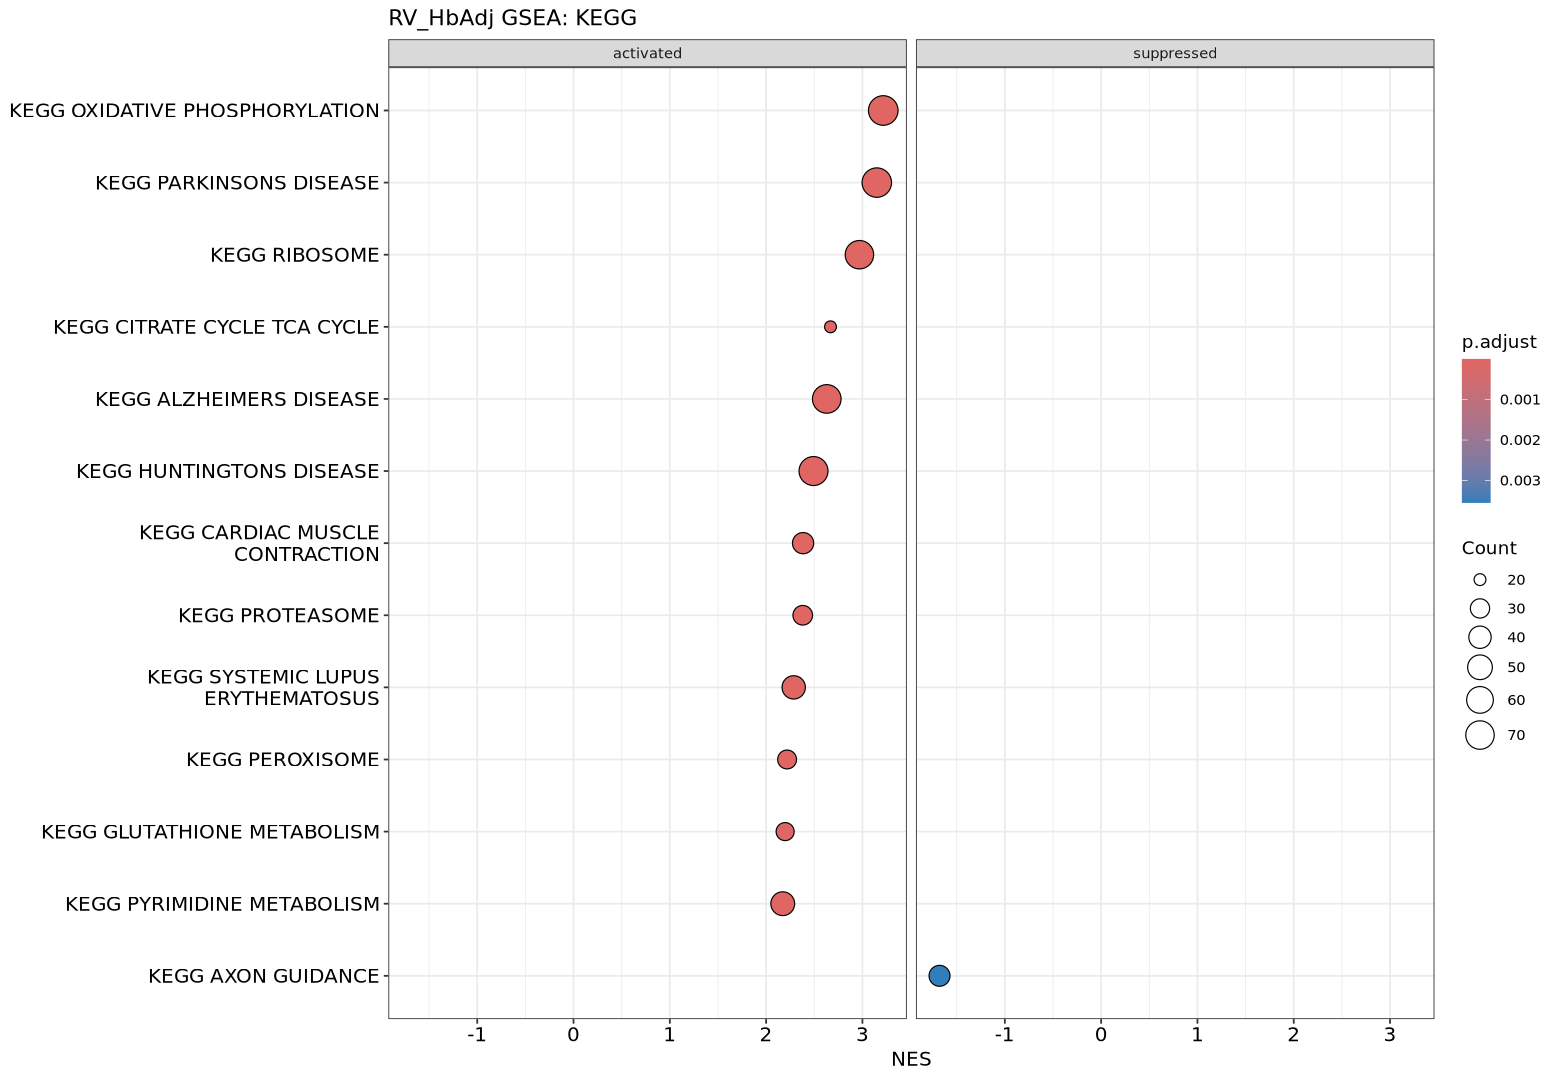

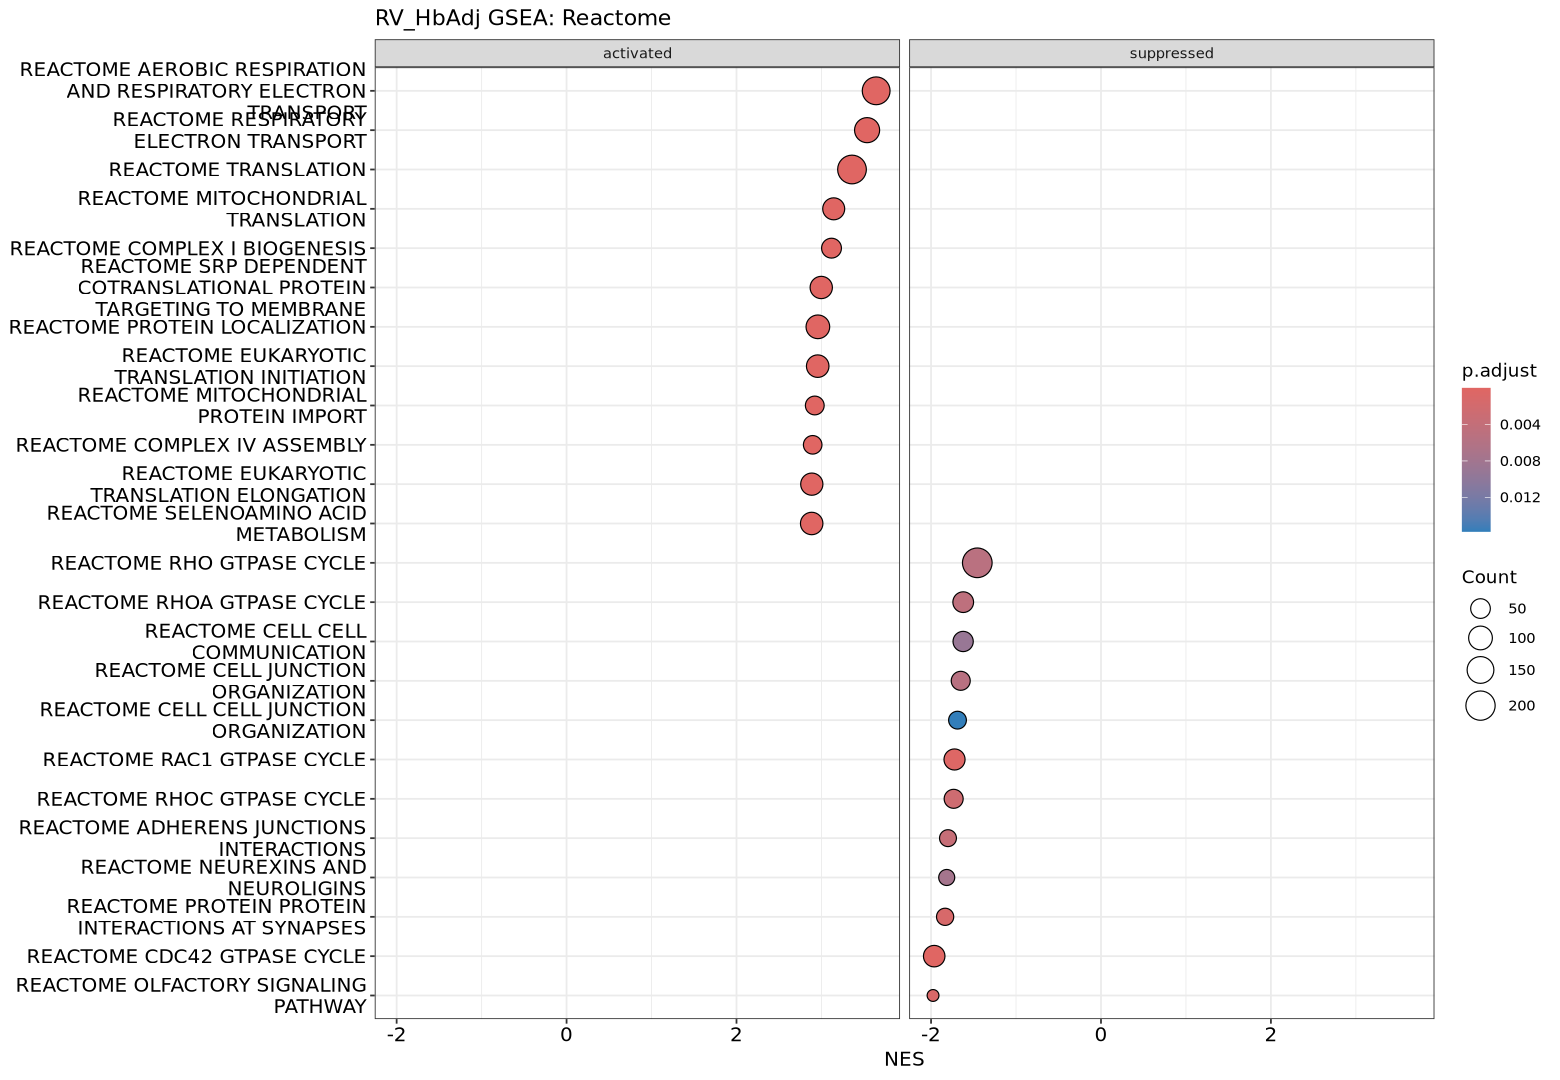

In [9]:
options(repr.plot.width = 13, repr.plot.height = 9)
for (contrast_name in names(all_gsea)) {
  for (coll in names(all_gsea[[contrast_name]])) {
    res <- all_gsea[[contrast_name]][[coll]]
    if (is.null(res) || nrow(as.data.frame(res)) == 0) next
    title <- paste0(CONTRASTS[[contrast_name]]$label, " GSEA: ", coll)
    p <- plot_gsea_dotplot(res, show_n = 12, title = title)
    if (!is.null(p)) {
      print(p)
      ggsave(file.path(PLOTS_DIR,
                        paste0(CONTRASTS[[contrast_name]]$label,
                               "_GSEA_", coll, "_dotplot.pdf")),
             p, width = 13, height = 9)
    }
  }
}


Bar plot for: Hb_adjusted 
  Saved: enrichment_rv/plots/RV_HbAdj_gsea_bars_hallmark .{pdf,png}


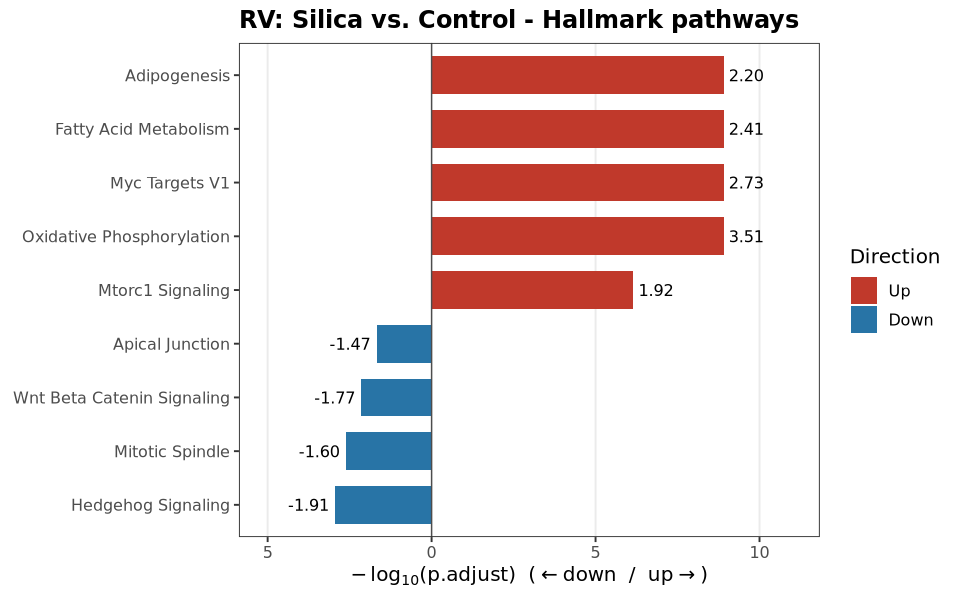

In [10]:
# === Publication-style horizontal bar plot ===
# Hallmark GSEA, top 5 up + top 5 down by padj.
# Saves both PDF (vector, for figure assembly) and PNG (300 dpi, for slides).

for (contrast_name in names(CONTRASTS)) {

  cat("\nBar plot for:", contrast_name, "\n")
  gsea_hall <- all_gsea[[contrast_name]][["Hallmark"]]

  p_bars <- plot_gsea_horizontal_bars(
    gsea_hall,
    n_up = 5, n_down = 5,
    title = ("RV: Silica vs. Control - Hallmark pathways")
  )

  if (is.null(p_bars)) {
    cat("  (no Hallmark pathways to plot)\n")
    next
  }

  options(repr.plot.width = 8, repr.plot.height = 5)
  print(p_bars)

  bar_base <- file.path(PLOTS_DIR,
                        paste0(CONTRASTS[[contrast_name]]$label,
                               "_gsea_bars_hallmark"))
  ggsave(paste0(bar_base, ".pdf"), p_bars, width = 8, height = 5)
  ggsave(paste0(bar_base, ".png"), p_bars, width = 8, height = 5, dpi = 300)
  cat("  Saved:", bar_base, ".{pdf,png}\n")
}

## 8. Session info

In [11]:
sessionInfo()
capture.output(sessionInfo(),
               file = file.path(OUTPUT_DIR, "sessionInfo.txt"))
Sys.time()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.6 (Plow)

Matrix products: default
BLAS/LAPACK: /nfs/roberts/project/pi_epm38/jfd42/ycrc_conda/envs/20260429bulkrnaseq/lib/libopenblasp-r0.3.32.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggrepel_0.9.6          RColorBrewer_1.1-3     openxlsx_4.2.8        
 [4] msigdbr_25.1.1         enrichplot_1.22.0      clusterProfiler_4.10.0
 [7] lubridate_1.9.4        forcats_1.0.0          stringr_1.5.2         
[10] 

[1] "2026-07-31 14:13:16 EDT"